# Log Normal Distribution
--------------------

x = e^(mu + sig*z)

where:
* e is euler's constant
* mu is the expected value (mean)
* sig is the SD of the variable natural log
* Z is a standard normal variable



In [1]:
import numpy as np
import os
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
path_root = 'PATH_TO_ROOT_DIR'
# file_name = 'enron'
file_name = 'contracts'

### Fit Distribution

In [ ]:
import os

by_type = {}
for filename in os.listdir(f'{path_root}/{file_name}'):
    filepath = os.path.join(f'{path_root}/{file_name}', filename)
    if os.path.isfile(filepath):
        ext = os.path.splitext(filename)[1].lower()
        size = os.path.getsize(filepath)
        if ext not in by_type:
            by_type[ext] = []
        by_type[ext].append(size)

for ext, sizes in by_type.items():
    sizes = np.array(sizes)
    shape, loc, scale = stats.lognorm.fit(sizes, floc=0)
    log_sizes = np.log(sizes)
    mu = np.mean(log_sizes)
    sigma = np.std(log_sizes, ddof=1)
    ks_stat, p_val = stats.kstest(sizes, 'lognorm', args=(shape, loc, scale))
    
    print(f"\n{ext} files (n={len(sizes)}):")
    print(f"  LogNormal(μ={mu:.2f}, σ={sigma:.2f})")
    print(f"  p-value: {p_val:.4f}, fit: {p_val > 0.05}")
    print(f"  Range: {sizes.min():,} to {sizes.max():,}")


.pdf files (n=9095):
  LogNormal(μ=10.17, σ=1.23)
  p-value: 0.0000, fit: False
  Range: 1,717 to 12,752,648

.htm files (n=9158):
  LogNormal(μ=10.97, σ=1.43)
  p-value: 0.0004, fit: False
  Range: 255 to 36,403,016

.txt files (n=8796):
  LogNormal(μ=10.86, σ=1.44)
  p-value: 0.0000, fit: False
  Range: 278 to 18,670,104

.docx files (n=8853):
  LogNormal(μ=10.86, σ=0.37)
  p-value: 0.0000, fit: False
  Range: 36,796 to 914,342

.rtf files (n=8833):
  LogNormal(μ=10.91, σ=1.42)
  p-value: 0.0000, fit: False
  Range: 345 to 37,447,169


In [4]:
distributions = ['lognorm', 'gamma', 'weibull_min', 'pareto', 'expon']

for ext, sizes in by_type.items():
    sizes = np.array(sizes)
    print(f"\n{ext} files:")
    
    best_dist = None
    best_ks = float('inf')
    
    for dist_name in distributions:
        dist = getattr(stats, dist_name)
        try:
            params = dist.fit(sizes)
            ks_stat, p_val = stats.kstest(sizes, dist_name, args=params)
            print(f"  {dist_name:15s}: KS={ks_stat:.4f}, p={p_val:.4f}")
            
            if ks_stat < best_ks:
                best_ks = ks_stat
                best_dist = dist_name
        except:
            print(f"  {dist_name:15s}: fit failed")
    
    print(f"  → Best: {best_dist} (KS={best_ks:.4f})")


.pdf files:
  lognorm        : KS=0.0199, p=0.0014
  gamma          : KS=0.9999, p=0.0000
  weibull_min    : KS=0.5473, p=0.0000
  pareto         : KS=0.0288, p=0.0000
  expon          : KS=0.2000, p=0.0000
  → Best: lognorm (KS=0.0199)

.htm files:
  lognorm        : KS=0.0215, p=0.0004
  gamma          : KS=0.9999, p=0.0000
  weibull_min    : KS=0.4694, p=0.0000
  pareto         : KS=0.0233, p=0.0001
  expon          : KS=0.2219, p=0.0000
  → Best: lognorm (KS=0.0215)

.txt files:
  lognorm        : KS=0.0243, p=0.0001
  gamma          : KS=0.9999, p=0.0000
  weibull_min    : KS=0.3595, p=0.0000
  pareto         : KS=0.0243, p=0.0001
  expon          : KS=0.2222, p=0.0000
  → Best: pareto (KS=0.0243)

.docx files:
  lognorm        : KS=0.0287, p=0.0000
  gamma          : KS=0.9998, p=0.0000
  weibull_min    : KS=0.1512, p=0.0000
  pareto         : KS=0.0449, p=0.0000
  expon          : KS=0.1426, p=0.0000
  → Best: lognorm (KS=0.0287)

.rtf files:
  lognorm        : KS=0.0303, p=0.0

### Fit Lognormal Parameters

In [5]:
def get_filesizes(full_path):
    file_sizes = []
    for filename in os.listdir(full_path):
        filepath = os.path.join(full_path, filename)
        if os.path.isfile(filepath):
            file_sizes.append(os.path.getsize(filepath))
    return np.array(file_sizes)

def fit_model(file_sizes):
    log_sizes = np.log(file_sizes)
    mu = np.mean(log_sizes)
    sigma = np.std(log_sizes, ddof=1)
    return mu, sigma

def print_results(folder, mu, sigma):
    print(f"{folder} Lognormal params:")
    print(f"μ = {mu} | σ = {sigma}")

In [ ]:
sigmas = [] ; mus = []
for folder in ('contracts', 'enron'):
    file_sizes = get_filesizes(f'{path_root}/{folder}')
    mu, sigma = fit_model(file_sizes)
    print_results(folder, mu, sigma)
    sigmas.append(sigma) ; mus.append(mu)
print('-----------------------')
print(f'avg μ: {sum(mus)/len(mus)} | avg σ : {sum(sigmas)/len(sigmas)}')


contracts Lognormal params:
μ = 10.754513342574738 | σ = 1.2824863777197535
enron Lognormal params:
μ = 8.362216910168561 | σ = 2.0394688684150664
-----------------------
avg μ: 9.55836512637165 | avg σ : 1.66097762306741


---------------------
# Analytics on the Entire Corpora

In [ ]:
from pathlib import Path
import statistics
import os
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
corpora_path = 'corpora_path'
corpora_dir = ['IA_enron', 'contracts_20240515']

In [ ]:
def get_file_stats(directory):
    sizes = []
    
    for root, dirs, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            try:
                size = os.path.getsize(filepath)
                sizes.append(size)
            except (OSError, FileNotFoundError):
                continue
    
    if not sizes:
        print("No files found!")
        return None
    
    return np.array(sizes)

def fit_distributions(data):
    distributions = [
        stats.lognorm,
        stats.gamma,
        stats.expon,
        stats.weibull_min,
        stats.pareto,
        stats.norm,
        stats.beta,
        stats.exponweib,
    ]
    
    results = []
    
    print("Fitting distributions...")
    print(f"{'='*70}")
    
    for dist in distributions:
        try:
            params = dist.fit(data)
            ks_stat, ks_p_value = stats.kstest(data, dist.name, args=params)
            log_likelihood = np.sum(dist.logpdf(data, *params))
            k = len(params)
            aic = 2 * k - 2 * log_likelihood
            n = len(data)
            bic = k * np.log(n) - 2 * log_likelihood
            
            results.append({
                'distribution': dist.name,
                'params': params,
                'ks_statistic': ks_stat,
                'ks_p_value': ks_p_value,
                'aic': aic,
                'bic': bic
            })
            
        except Exception as e:
            print(f"Could not fit {dist.name}: {e}")
            continue
    
    results.sort(key=lambda x: x['aic'])

    print(f"\n{'Distribution':<15} {'KS Stat':<12} {'KS p-value':<12} {'AIC':<15} {'BIC':<15}")
    print(f"{'-'*70}")
    
    for r in results:
        print(f"{r['distribution']:<15} {r['ks_statistic']:<12.6f} {r['ks_p_value']:<12.6f} {r['aic']:<15.2f} {r['bic']:<15.2f}")
    
    print(f"\n{'='*70}")
    print(f"Best fit: {results[0]['distribution']} (lowest AIC)")
    print(f"Parameters: {results[0]['params']}")
    
    return results

def plot_fit(data, best_result):
    """Plot the data histogram with the best-fit distribution"""
    
    dist_name = best_result['distribution']
    params = best_result['params']
    dist = getattr(stats, dist_name)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(data, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')

    x = np.linspace(data.min(), data.max(), 1000)
    ax1.plot(x, dist.pdf(x, *params), 'r-', linewidth=2, label=f'{dist_name} fit')
    ax1.set_xlabel('File Size (bytes)')
    ax1.set_ylabel('Density')
    ax1.set_title(f'File Size Distribution with {dist_name} Fit')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.hist(np.log10(data[data > 0]), bins=50, density=True, alpha=0.7, color='green', edgecolor='black')
    log_x = np.linspace(np.log10(data[data > 0].min()), np.log10(data.max()), 1000)

    ax2.set_xlabel('Log10(File Size)')
    ax2.set_ylabel('Density')
    ax2.set_title('File Size Distribution (Log Scale)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig('file_size_distribution.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'file_size_distribution.png'")
    plt.show()

def print_basic_stats(data):
    """Print basic statistics"""
    print(f"\nBasic Statistics:")
    print(f"{'='*50}")
    print(f"Total files: {len(data):,}")
    print(f"Total size: {data.sum():,} bytes ({data.sum()/1024/1024:.2f} MB)")
    print(f"Mean: {data.mean():,.2f} bytes ({data.mean()/1024:.2f} KB)")
    print(f"Median: {np.median(data):,} bytes ({np.median(data)/1024:.2f} KB)")
    print(f"Std Dev: {data.std():,.2f} bytes")
    print(f"Min: {data.min():,} bytes")
    print(f"Max: {data.max():,} bytes ({data.max()/1024/1024:.2f} MB)")
    print(f"25th percentile: {np.percentile(data, 25):,} bytes")
    print(f"75th percentile: {np.percentile(data, 75):,} bytes")
    print(f"95th percentile: {np.percentile(data, 95):,} bytes")




Basic Statistics:
Total files: 1,038,766
Total size: 156,024,940,649 bytes (148796.98 MB)
Mean: 150,202.20 bytes (146.68 KB)
Median: 51,966.0 bytes (50.75 KB)
Std Dev: 525,391.09 bytes
Min: 0 bytes
Max: 113,809,278 bytes (108.54 MB)
25th percentile: 21,019.0 bytes
75th percentile: 123,451.5 bytes
95th percentile: 607,232.25 bytes
Fitting distributions...


/home/saltlick/Desktop/work/Sherlock_HoLLMes/.venv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6930: RuntimeWarning: divide by zero encountered in log
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/home/saltlick/Desktop/work/Sherlock_HoLLMes/.venv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))



Distribution    KS Stat      KS p-value   AIC             BIC            
----------------------------------------------------------------------
lognorm         0.021832     0.000000     26243785.79     26243821.35    
pareto          0.023748     0.000000     26259391.08     26259426.64    
exponweib       0.049567     0.000000     26268596.16     26268643.57    
weibull_min     0.079992     0.000000     26429416.52     26429452.08    
expon           0.220734     0.000000     26841172.46     26841196.17    
beta            0.088731     0.000000     27622658.12     27622705.53    
norm            0.387597     0.000000     30312934.21     30312957.91    
gamma           1.000000     0.000000     inf             inf            

Best fit: lognorm (lowest AIC)
Parameters: (np.float64(1.4167347066388865), np.float64(-245.2484047699508), np.float64(52307.61741521729))

Plot saved as 'file_size_distribution.png'


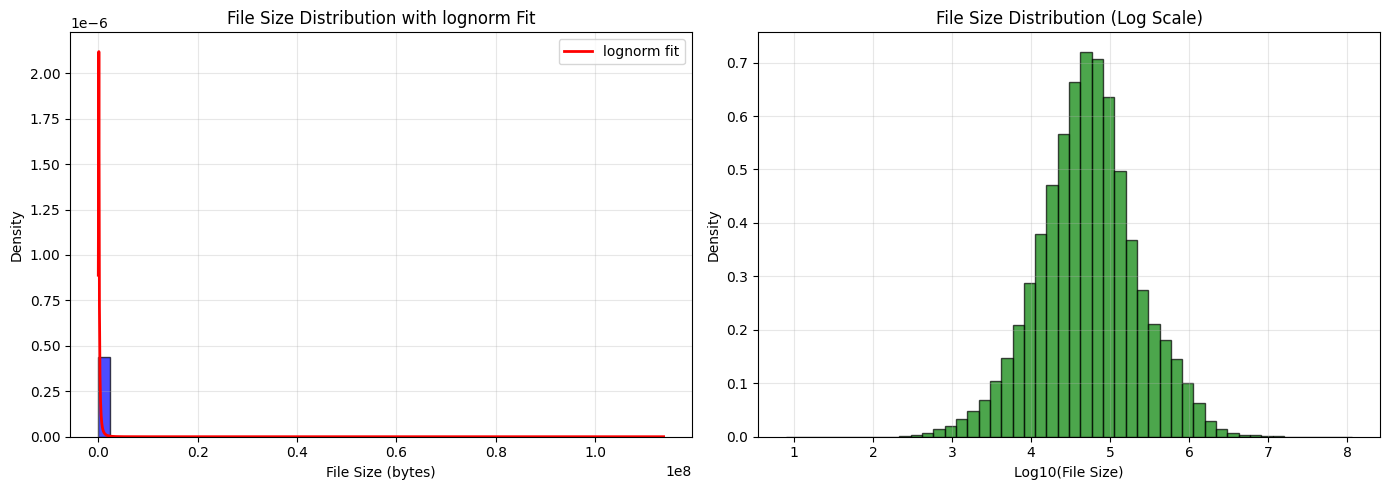

In [ ]:
if __name__ == "__main__":
    directory = f'{corpora_path}/{corpora_dir[1]}'
    sizes = get_file_stats(directory)
    
    if sizes is not None and len(sizes) > 0:
        print_basic_stats(sizes)
        results = fit_distributions(sizes)
        
        if results:
            plot_fit(sizes, results[0])
# directory = f'{corpora_path}/{corpora_dir[1]}'
# get_file_stats(directory)


Basic Statistics:
Total files: 3,424,353
Total size: 258,195,968,648 bytes (246234.86 MB)
Mean: 75,399.93 bytes (73.63 KB)
Median: 1,175.0 bytes (1.15 KB)
Std Dev: 6,803,174.47 bytes
Min: 0 bytes
Max: 4,114,600,777 bytes (3923.99 MB)
25th percentile: 639.0 bytes
75th percentile: 5,110.0 bytes
95th percentile: 122,880.0 bytes
Fitting distributions...


/home/saltlick/Desktop/work/Sherlock_HoLLMes/.venv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6930: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/home/saltlick/Desktop/work/Sherlock_HoLLMes/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)



Distribution    KS Stat      KS p-value   AIC             BIC            
----------------------------------------------------------------------
lognorm         0.507112     0.000000     30372832.27     30372871.41    
exponweib       0.242747     0.000000     66645674.26     66645726.45    
pareto          0.150193     0.000000     66884183.05     66884222.19    
weibull_min     0.475645     0.000000     67693942.45     67693981.59    
expon           0.688009     0.000000     83763524.58     83763550.67    
norm            0.495579     0.000000     117467902.76    117467928.85   
gamma           1.000000     0.000000     inf             inf            
beta            0.452662     0.000000     inf             inf            

Best fit: lognorm (lowest AIC)
Parameters: (np.float64(82.19883843040829), np.float64(-5e-324), np.float64(0.24828183610421842))

Plot saved as 'file_size_distribution.png'


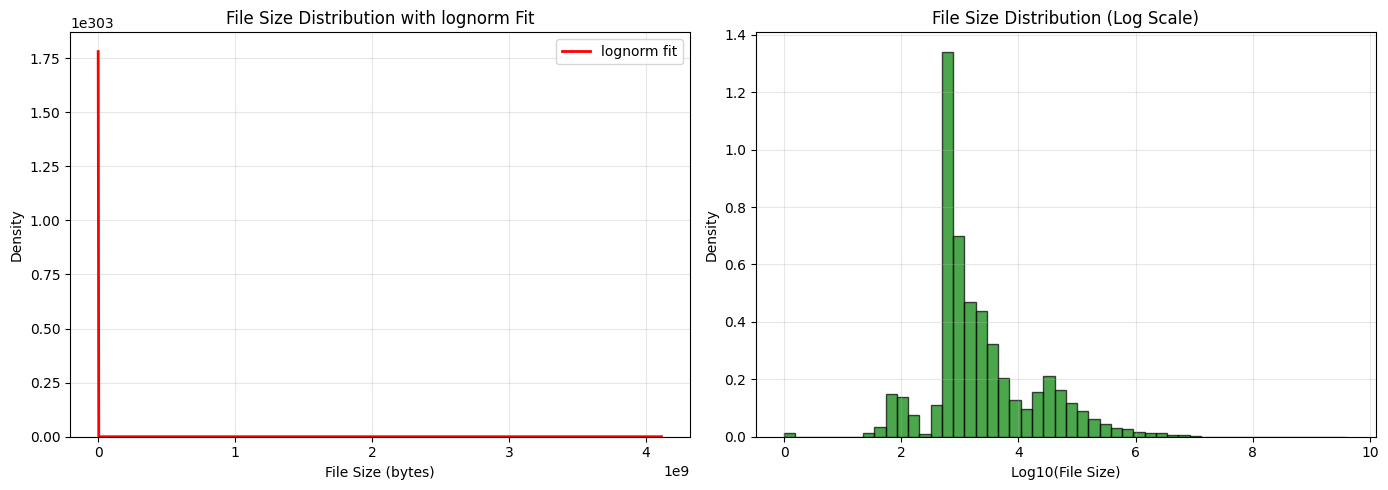

In [ ]:
if __name__ == "__main__":
    directory = f'{corpora_path}/{corpora_dir[0]}'
    sizes = get_file_stats(directory)
    
    if sizes is not None and len(sizes) > 0:
        print_basic_stats(sizes)
        results = fit_distributions(sizes)
        if results:
            plot_fit(sizes, results[0])

Distribution    KS Stat      KS p-value   AIC             BIC            
----------------------------------------------------------------------
lognorm         0.021832     0.000000     26243785.79     26243821.35    
pareto          0.023748     0.000000     26259391.08     26259426.64    
exponweib       0.049567     0.000000     26268596.16     26268643.57    
weibull_min     0.079992     0.000000     26429416.52     26429452.08    
expon           0.220734     0.000000     26841172.46     26841196.17    
beta            0.088731     0.000000     27622658.12     27622705.53    
norm            0.387597     0.000000     30312934.21     30312957.91    
gamma           1.000000     0.000000     inf             inf            

======================================================================
Best fit: lognorm (lowest AIC)
Parameters: (np.float64(1.4167347066388865), np.float64(-245.2484047699508), np.float64(52307.61741521729))

Distribution    KS Stat      KS p-value   AIC             BIC            
----------------------------------------------------------------------
lognorm         0.507112     0.000000     30372832.27     30372871.41    
exponweib       0.242747     0.000000     66645674.26     66645726.45    
pareto          0.150193     0.000000     66884183.05     66884222.19    
weibull_min     0.475645     0.000000     67693942.45     67693981.59    
expon           0.688009     0.000000     83763524.58     83763550.67    
norm            0.495579     0.000000     117467902.76    117467928.85   
gamma           1.000000     0.000000     inf             inf            
beta            0.452662     0.000000     inf             inf            

======================================================================
Best fit: lognorm (lowest AIC)
Parameters: (np.float64(82.19883843040829), np.float64(-5e-324), np.float64(0.24828183610421842))


In [ ]:
import os
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

def get_file_stats(directory):
    sizes = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            try:
                size = os.path.getsize(filepath)
                if size > 0:
                    sizes.append(size)
            except (OSError, FileNotFoundError):
                continue
    return np.array(sizes)

def fit_mixture_model(data, n_components=3):
    log_data = np.log10(data).reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(log_data)
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_

    sorted_idx = np.argsort(means)
    means = means[sorted_idx]
    stds = stds[sorted_idx]
    weights = weights[sorted_idx]
    
    print(f"\nMixture Model Results ({n_components} components):")
    print(f"{'='*70}")
    print(f"{'Component':<12} {'Weight':<12} {'Mean (log10)':<15} {'Mean (bytes)':<15} {'Std (log10)':<12}")
    print(f"{'-'*70}")
    
    for i in range(n_components):
        mean_bytes = 10**means[i]
        print(f"Component {i+1:<2} {weights[i]:<12.3f} {means[i]:<15.3f} {mean_bytes:<15,.0f} {stds[i]:<12.3f}")
    
    print(f"\nInterpretation:")
    print(f"Component 1: {10**means[0]:.0f} bytes - {get_file_type_guess(means[0])}")
    print(f"Component 2: {10**means[1]:.0f} bytes - {get_file_type_guess(means[1])}")
    print(f"Component 3: {10**means[2]:.0f} bytes - {get_file_type_guess(means[2])}")

    bic = gmm.bic(log_data)
    aic = gmm.aic(log_data)
    print(f"\nModel Quality:")
    print(f"BIC: {bic:,.2f}")
    print(f"AIC: {aic:,.2f}")
    
    return gmm, log_data, means, stds, weights

def get_file_type_guess(log_mean):
    """Guess file type based on size"""
    size = 10**log_mean
    if size < 500:
        return "Headers/metadata/empty emails"
    elif size < 5000:
        return "Typical email bodies"
    elif size < 50000:
        return "Longer emails/small attachments"
    else:
        return "Emails with larger attachments"

def plot_mixture(data, gmm, log_data, means, stds, weights):
    """Plot the data with mixture model overlay"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    ax1 = axes[0, 0]
    ax1.hist(log_data, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black')

    x = np.linspace(log_data.min(), log_data.max(), 1000)
    colors = ['red', 'green', 'orange']
    
    for i in range(len(means)):
        component = weights[i] * stats.norm.pdf(x, means[i], stds[i])
        ax1.plot(x, component, color=colors[i], linewidth=2, 
                label=f'Component {i+1}: {10**means[i]:.0f} bytes ({weights[i]:.1%})')

    total = sum(weights[i] * stats.norm.pdf(x, means[i], stds[i]) for i in range(len(means)))
    ax1.plot(x, total, 'k-', linewidth=3, label='Total Mixture')
    
    ax1.set_xlabel('Log10(File Size)')
    ax1.set_ylabel('Density')
    ax1.set_title('File Size Distribution with Gaussian Mixture Model')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    ax2.hist(data, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black')
    ax2.set_xlabel('File Size (bytes)')
    ax2.set_ylabel('Density')
    ax2.set_title('File Size Distribution (Original Scale)')
    ax2.set_xlim([0, np.percentile(data, 99)])
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    labels = gmm.predict(log_data)
    for i in range(len(means)):
        mask = labels == np.argsort(means)[i]
        ax3.hist(log_data[mask], bins=50, alpha=0.6, label=f'Component {i+1}', color=colors[i])
    ax3.set_xlabel('Log10(File Size)')
    ax3.set_ylabel('Count')
    ax3.set_title('Files by Component Assignment')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    sorted_data = np.sort(log_data.flatten())
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax4.plot(sorted_data, cumulative, linewidth=2)
    
    for i, mean in enumerate(means):
        ax4.axvline(mean, color=colors[i], linestyle='--', linewidth=2, 
                   label=f'Component {i+1} mean')
    
    ax4.set_xlabel('Log10(File Size)')
    ax4.set_ylabel('Cumulative Probability')
    ax4.set_title('Cumulative Distribution Function')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('enron_mixture_analysis.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'enron_mixture_analysis.png'")
    plt.show()

def test_different_n_components(data):
    """Test different numbers of components to find optimal"""
    log_data = np.log10(data).reshape(-1, 1)
    
    print("\nTesting different numbers of components:")
    print(f"{'N Components':<15} {'BIC':<20} {'AIC':<20}")
    print(f"{'-'*55}")
    
    bics = []
    aics = []
    
    for n in range(2, 7):
        gmm = GaussianMixture(n_components=n, random_state=42)
        gmm.fit(log_data)
        bic = gmm.bic(log_data)
        aic = gmm.aic(log_data)
        bics.append(bic)
        aics.append(aic)
        print(f"{n:<15} {bic:<20,.2f} {aic:<20,.2f}")
    
    optimal_n = np.argmin(bics) + 2
    print(f"\nOptimal number of components (by BIC): {optimal_n}")
    return optimal_n


Scanning files...
Found 3,382,980 files
Size range: 1 to 4,114,600,777 bytes

Testing different numbers of components:
N Components    BIC                  AIC                 
-------------------------------------------------------
2               8,367,775.11         8,367,709.94        
3               7,458,038.23         7,457,933.96        
4               7,082,263.96         7,082,120.58        
5               7,039,712.19         7,039,529.71        
6               7,042,544.17         7,042,322.59        

Optimal number of components (by BIC): 5

Mixture Model Results (3 components):
Component    Weight       Mean (log10)    Mean (bytes)    Std (log10) 
----------------------------------------------------------------------
Component 1  0.325        2.846           702             0.109       
Component 2  0.456        3.211           1,626           0.840       
Component 3  0.219        4.346           22,206          0.957       

Interpretation:
Component 1: 702 bytes -

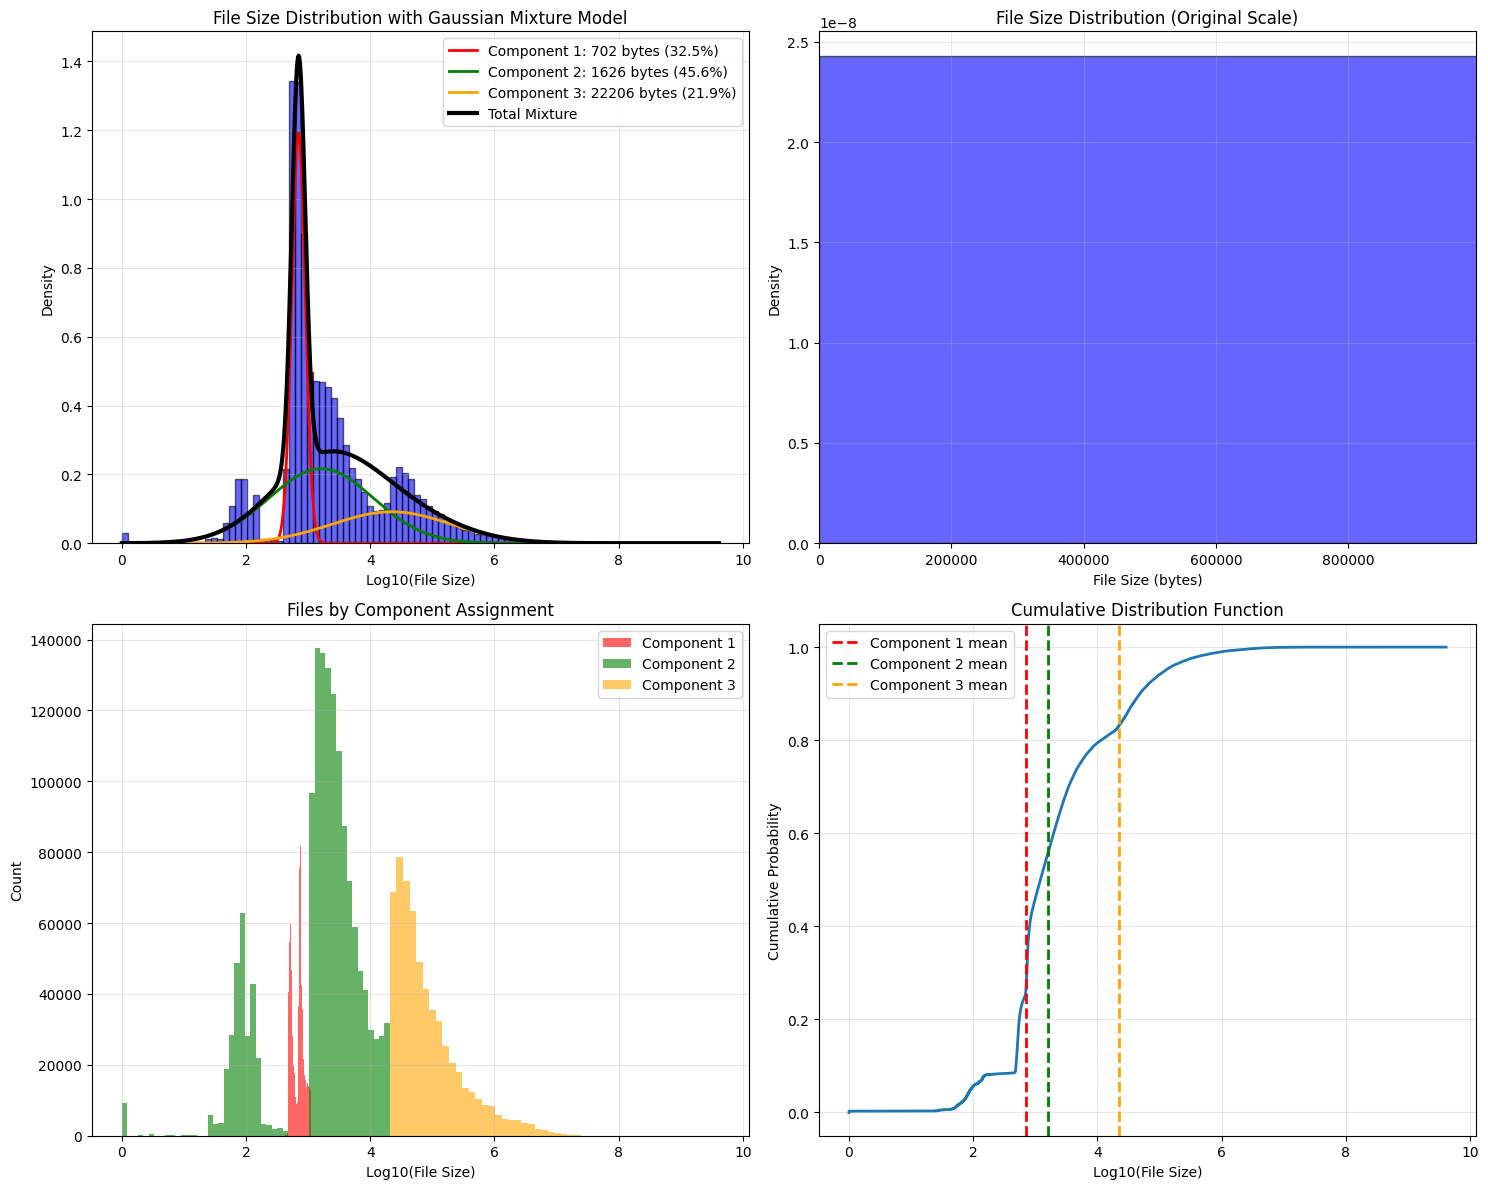

In [ ]:
if __name__ == "__main__":
    directory = f'{corpora_path}/{corpora_dir[0]}'
    
    # Get file sizes
    print("Scanning files...")
    sizes = get_file_stats(directory)
    
    if sizes is not None and len(sizes) > 0:
        print(f"Found {len(sizes):,} files")
        print(f"Size range: {sizes.min():,} to {sizes.max():,} bytes")

        optimal_n = test_different_n_components(sizes)

        n_components = 3  # 3 humps
        gmm, log_data, means, stds, weights = fit_mixture_model(sizes, n_components)
        plot_mixture(sizes, gmm, log_data, means, stds, weights)


Mixture Model Results (5 components):
Component    Weight       Mean (log10)    Mean (bytes)    Std (log10) 
----------------------------------------------------------------------
Component 1  0.090        1.938           87              0.461       
Component 2  0.368        2.833           681             0.103       
Component 3  0.324        3.359           2,284           0.273       
Component 4  0.166        4.535           34,309          0.372       
Component 5  0.052        5.471           295,492         0.638       

Interpretation:
Component 1: 87 bytes - Headers/metadata/empty emails
Component 2: 681 bytes - Typical email bodies
Component 3: 2284 bytes - Typical email bodies

Model Quality:
BIC: 7,039,712.19
AIC: 7,039,529.71


IndexError: list index out of range

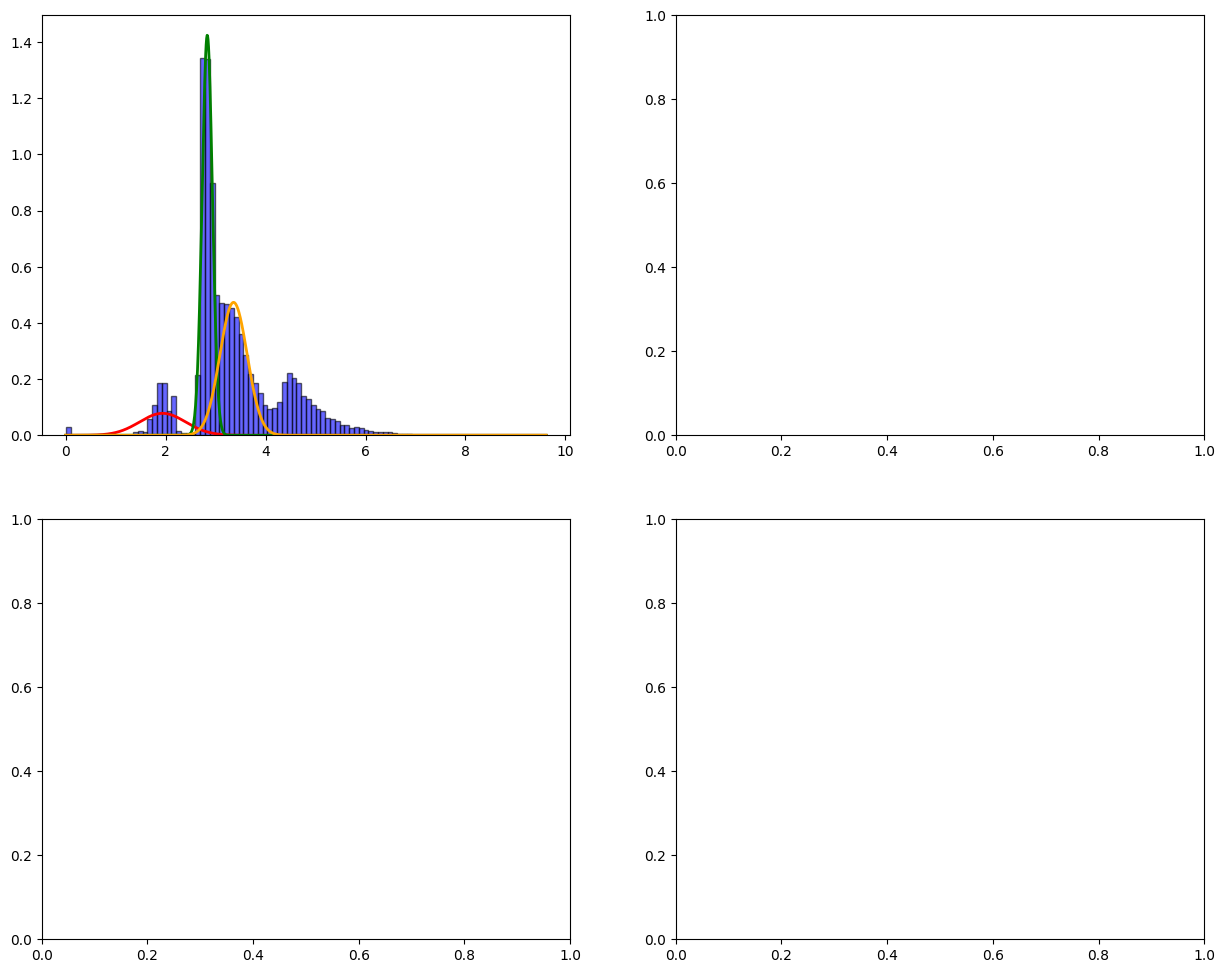

In [16]:
gmm5, log_data5, means5, stds5, weights5 = fit_mixture_model(sizes, n_components=5)
plot_mixture(sizes, gmm5, log_data5, means5, stds5, weights5)

The Five Populations:

Component 1 (9%): ~87 bytes

Headers, routing info, or nearly-empty emails
Very small files - probably automated messages, bounce-backs, or calendar invites
~304,000 files

Component 2 (36.8%): ~681 bytes

Short emails - quick replies, brief updates
Tightest distribution (std = 0.103) - very consistent size
The largest single population (~1.25 million files)
This is professional communication at its most efficient

Component 3 (32.4%): ~2.3 KB

Standard emails - the typical business email with context
Still fairly tight (std = 0.273)
~1.1 million files
Emails with a few paragraphs of content

Component 4 (16.6%): ~34 KB

Longer emails or small attachments
Could be: email threads, forwarded chains, small spreadsheets/docs
~561,000 files
More variable (std = 0.372)

Component 5 (5.2%): ~295 KB

Emails with substantial attachments
Large spreadsheets, presentations, PDFs
Only ~176,000 files but probably consuming significant storage
Very wide spread (std = 0.638) - attachment sizes vary wildly

In [20]:
final_mu = sum([9.0723, 10.866])/2
final_sigma = sum([1.8434, 1.4167])/2

print(f'final mu: {final_mu} | final sigma: {final_sigma}')

final mu: 9.969149999999999 | final sigma: 1.63005
